In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

In [2]:
Aus = pd.read_csv("Data/AustraliaGPModified.csv")
Jap = pd.read_csv("Data/JapanGPModified.csv")

In [3]:
Aus

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,Race_Result,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT
0,ALB,83.130,81.847000,81.664000,36.650031,20.898312,42.942393,100.398929,11,80.941,15.0,12.0,0,19.88,False,False
1,ANT,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,2.0,0,19.88,False,False
2,BEA,82.682,81.326000,80.778000,39.039839,20.835774,41.873786,102.072750,15,80.311,12.0,7.0,0,19.88,False,False
3,BOR,81.696,81.668000,80.459000,39.209964,20.777286,46.708920,99.549182,9,80.221,10.0,9.0,0,19.88,True,False
4,BOT,84.022,83.660000,83.514000,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0,19.0,0,19.88,True,False
5,COL,83.325,82.619000,81.413000,38.297846,22.258222,45.171583,101.418318,11,81.270,16.0,14.0,0,19.88,True,False
6,GAS,84.035,82.167000,81.071000,37.261133,22.742125,41.458429,99.050308,11,80.501,14.0,10.0,0,19.88,True,False
7,HAD,81.087,80.941000,80.137000,36.938357,23.917321,42.749958,99.028217,13,79.303,3.0,20.0,0,19.88,True,False
8,HAM,80.736,80.050000,79.669000,36.481677,21.753969,43.648655,99.920000,13,79.478,7.0,4.0,0,19.88,False,False
9,HUL,81.969,81.351000,81.067000,34.139485,20.528765,41.426839,93.962483,10,80.303,11.0,22.0,0,19.88,True,False


In [6]:
X = Aus.drop(columns=['Driver','Race_Result'])
y = Aus['Race_Result']

In [7]:
X

,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT
0,83.130,81.847000,81.664000,36.650031,20.898312,42.942393,100.398929,11,80.941,15.0,0,19.88,False,False
1,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,0,19.88,False,False
2,82.682,81.326000,80.778000,39.039839,20.835774,41.873786,102.072750,15,80.311,12.0,0,19.88,False,False
3,81.696,81.668000,80.459000,39.209964,20.777286,46.708920,99.549182,9,80.221,10.0,0,19.88,True,False
4,84.022,83.660000,83.514000,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0,0,19.88,True,False
5,83.325,82.619000,81.413000,38.297846,22.258222,45.171583,101.418318,11,81.270,16.0,0,19.88,True,False
6,84.035,82.167000,81.071000,37.261133,22.742125,41.458429,99.050308,11,80.501,14.0,0,19.88,True,False
7,81.087,80.941000,80.137000,36.938357,23.917321,42.749958,99.028217,13,79.303,3.0,0,19.88,True,False
8,80.736,80.050000,79.669000,36.481677,21.753969,43.648655,99.920000,13,79.478,7.0,0,19.88,False,False
9,81.969,81.351000,81.067000,34.139485,20.528765,41.426839,93.962483,10,80.303,11.0,0,19.88,True,False


In [8]:
y

0     12.0
1      2.0
2      7.0
3      9.0
4     19.0
5     14.0
6     10.0
7     20.0
8      4.0
9     22.0
10    13.0
11     3.0
12     8.0
13     5.0
14    11.0
15    16.0
16    21.0
17     1.0
18    15.0
19     6.0
Name: Race_Result, dtype: float64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.3, random_state = 42)

In [12]:
Scaler = StandardScaler()

In [15]:
X_scaled = Scaler.fit_transform(X)

In [13]:
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [72]:
model = RandomForestRegressor()

In [95]:
parameter ={
    'n_estimators': [20,25,50,70],
    'max_samples' :[3,4,5],
    'min_samples_leaf':[2],
    'random_state':[56]
}

In [96]:
regcv = GridSearchCV(model, param_grid=parameter, cv=3, scoring="neg_mean_absolute_error")

In [98]:
regcv.fit(X_train_scaled, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_samples': [3, 4, ...], 'min_samples_leaf': [2], 'n_estimators': [20, 25, ...], 'random_state': [56]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,25


In [99]:
y_predict = regcv.predict(X_scaled)

In [100]:
Final = Aus.copy()
Final['Predicted'] = y_predict

In [101]:
Final = Final.sort_values(by=['Predicted'])

In [102]:
Final = Final.reset_index(drop=True)
Final['Predicted_Position'] = Final.index+1

In [103]:
Final

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Qualifying_Time(s),Starting_Pos,Race_Result,rain_probability,Temprature,Tyre_Compound_MEDIUM,Tyre_Compound_SOFT,Predicted,Predicted_Position
0,BEA,82.682,81.326000,80.778000,39.039839,20.835774,41.873786,102.072750,15,80.311,12.0,7.0,0,19.88,False,False,13.13,1
1,RUS,81.371,80.049000,79.053000,38.616071,20.045714,42.000042,101.140833,13,78.518,1.0,1.0,0,19.88,False,False,13.13,2
2,PER,84.620,81.184895,84.397000,40.033500,21.311000,53.610000,118.806000,2,82.605,18.0,16.0,0,19.88,False,True,13.21,3
3,LAW,82.613,81.358000,80.890000,35.426966,21.766172,41.597720,97.647800,14,79.994,8.0,13.0,0,19.88,True,False,13.57,4
4,GAS,84.035,82.167000,81.071000,37.261133,22.742125,41.458429,99.050308,11,80.501,14.0,10.0,0,19.88,True,False,13.57,5
5,NOR,84.391,80.794000,80.443000,33.216286,20.360862,42.638692,92.236042,16,79.475,6.0,5.0,0,19.88,False,True,13.71,6
6,COL,83.325,82.619000,81.413000,38.297846,22.258222,45.171583,101.418318,11,81.270,16.0,14.0,0,19.88,True,False,13.73,7
7,LIN,81.313,80.922000,80.838000,39.199867,20.971933,43.092519,101.070296,15,81.247,9.0,8.0,0,19.88,False,True,13.75,8
8,BOT,84.022,83.660000,83.514000,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0,19.0,0,19.88,True,False,13.99,9
9,ANT,81.376,79.943000,80.324000,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,2.0,0,19.88,False,False,14.57,10


In [104]:
corr, _ = spearmanr(Final['Race_Result'], Final['Predicted_Position'])
print("Spearman Rank:", corr)

Spearman Rank: 0.3443609022556391


In [105]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

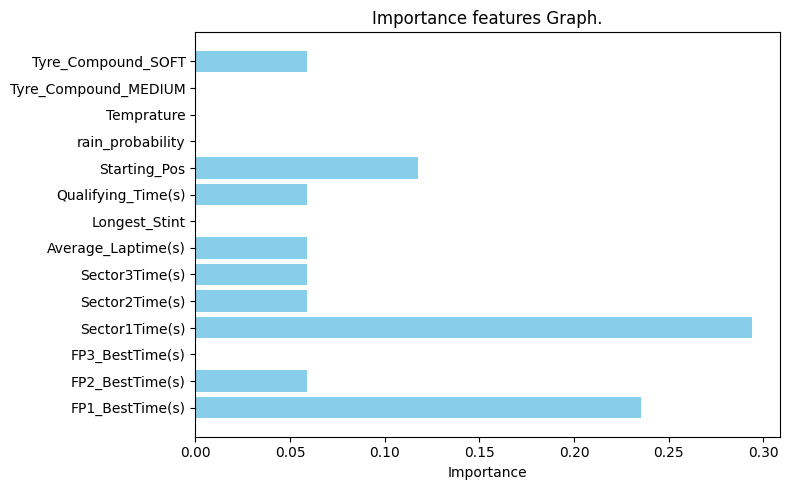

In [106]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Importance features Graph.")
plt.tight_layout()
plt.show()